### ============================================================================
## 1. IMPORT LIBRARIES
### ============================================================================

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import xgboost as xgb
import lightgbm as lgb
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("=" * 80)
print("CINEMA AUDIENCE FORECASTING CHALLENGE")
print("=" * 80)

CINEMA AUDIENCE FORECASTING CHALLENGE


### ============================================================================
## 2. LOAD DATASETS
### ============================================================================


In [2]:
print("\n" + "=" * 30)
print("STEP 1: LOADING DATASETS")
print("=" * 30)

# Define file paths
BASE_PATH = '/kaggle/input/Cinema_Audience_Forecasting_challenge/'

# Load all datasets
cinepos_theaters = pd.read_csv(f'{BASE_PATH}cinePOS_theaters/cinePOS_theaters.csv')
booknow_theaters = pd.read_csv(f'{BASE_PATH}booknow_theaters/booknow_theaters.csv')
theater_mapping = pd.read_csv(f'{BASE_PATH}movie_theater_id_relation/movie_theater_id_relation.csv')
cinepos_booking = pd.read_csv(f'{BASE_PATH}cinePOS_booking/cinePOS_booking.csv')
booknow_booking = pd.read_csv(f'{BASE_PATH}booknow_booking/booknow_booking.csv')
booknow_visits = pd.read_csv(f'{BASE_PATH}booknow_visits/booknow_visits.csv')
date_info = pd.read_csv(f'{BASE_PATH}date_info/date_info.csv')
sample_submission = pd.read_csv(f'{BASE_PATH}sample_submission/sample_submission.csv')

print(f"✓ CinePOS Theaters: {cinepos_theaters.shape}")
print(f"✓ BookNow Theaters: {booknow_theaters.shape}")
print(f"✓ Theater Mapping: {theater_mapping.shape}")
print(f"✓ CinePOS Bookings: {cinepos_booking.shape}")
print(f"✓ BookNow Bookings: {booknow_booking.shape}")
print(f"✓ BookNow Visits (Target): {booknow_visits.shape}")
print(f"✓ Date Info: {date_info.shape}")
print(f"✓ Sample Submission: {sample_submission.shape}")



STEP 1: LOADING DATASETS
✓ CinePOS Theaters: (4690, 5)
✓ BookNow Theaters: (829, 5)
✓ Theater Mapping: (150, 2)
✓ CinePOS Bookings: (1641966, 4)
✓ BookNow Bookings: (68336, 4)
✓ BookNow Visits (Target): (214046, 3)
✓ Date Info: (547, 2)
✓ Sample Submission: (38062, 2)


### ============================================================================
## 3. EXPLORATORY DATA ANALYSIS
### ============================================================================


STEP 2: EXPLORATORY DATA ANALYSIS

[1] Converting datetime columns...

[2] Feature Types:
   - Categorical: theater_type, theater_area, book_theater_id, day_of_week
   - Numerical: latitude, longitude, audience_count, tickets_sold
   - Datetime: show_date, show_datetime, booking_datetime

[3] Missing Data Analysis:
   - CinePOS Theaters latitude/longitude: 3861/4690 missing
   - BookNow Theaters book_theater_id: 515/829 missing

[4] Target Variable (audience_count) Statistics:
count    214046.000000
mean         41.616568
std          32.834918
min           2.000000
25%          18.000000
50%          34.000000
75%          58.000000
max        1350.000000
Name: audience_count, dtype: float64

✓ EDA visualizations saved as 'eda_visualizations.png'


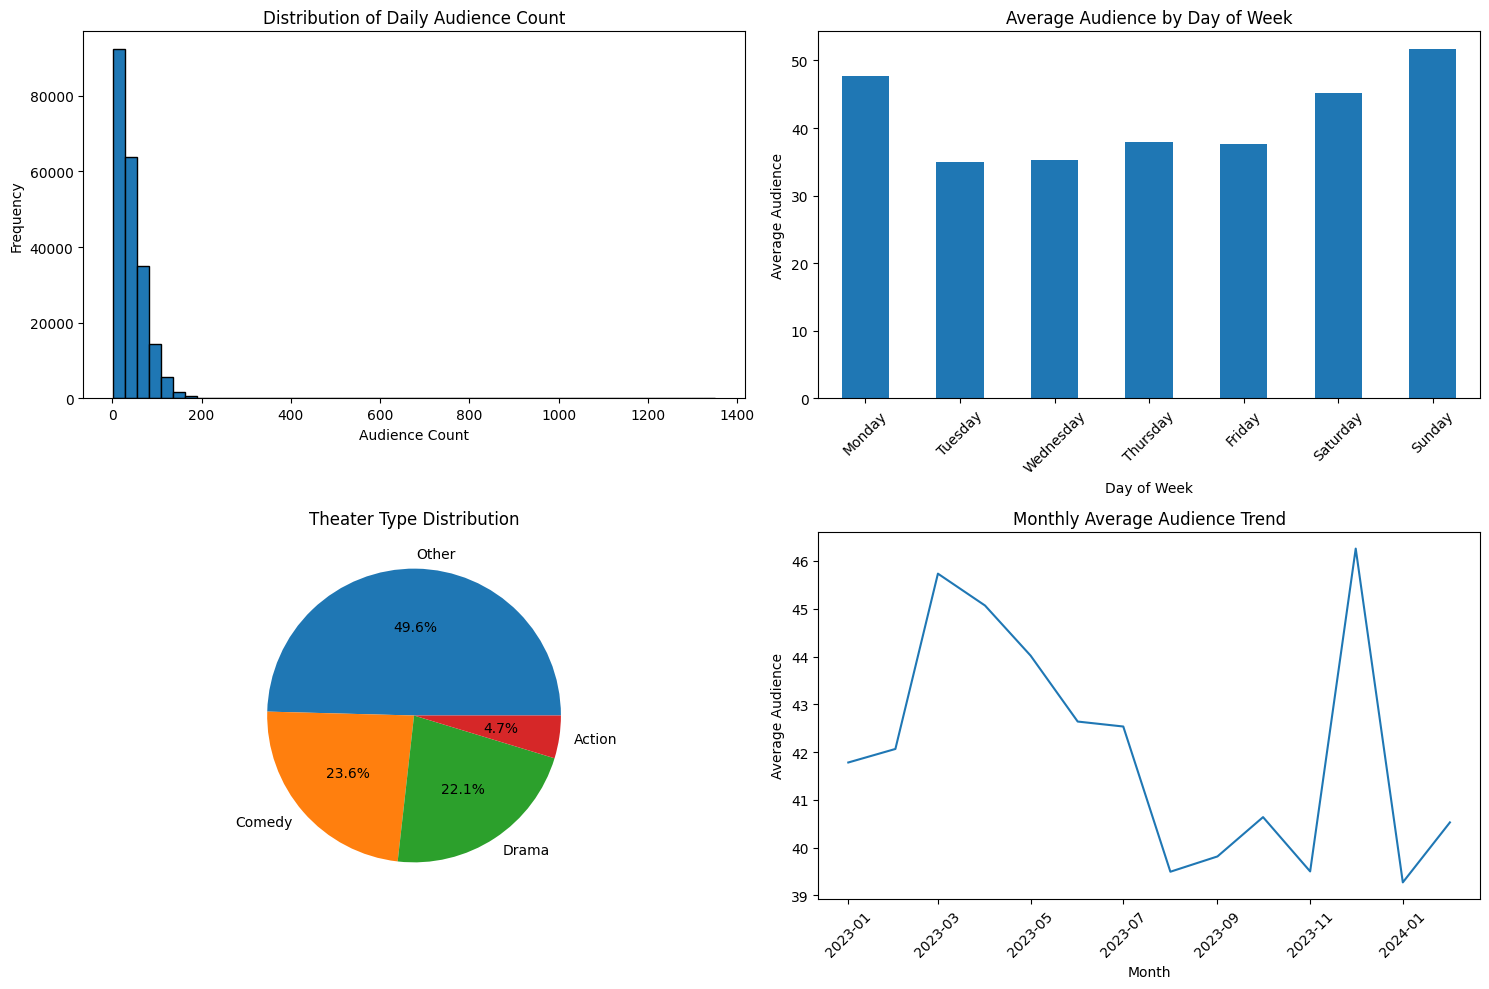

In [3]:
print("\n" + "=" * 80)
print("STEP 2: EXPLORATORY DATA ANALYSIS")
print("=" * 80)

# Convert datetime columns
print("\n[1] Converting datetime columns...")
booknow_visits['show_date'] = pd.to_datetime(booknow_visits['show_date'])
date_info['show_date'] = pd.to_datetime(date_info['show_date'])
cinepos_booking['show_datetime'] = pd.to_datetime(cinepos_booking['show_datetime'])
cinepos_booking['booking_datetime'] = pd.to_datetime(cinepos_booking['booking_datetime'])
booknow_booking['show_datetime'] = pd.to_datetime(booknow_booking['show_datetime'])
booknow_booking['booking_datetime'] = pd.to_datetime(booknow_booking['booking_datetime'])

# Feature type identification
print("\n[2] Feature Types:")
print(f"   - Categorical: theater_type, theater_area, book_theater_id, day_of_week")
print(f"   - Numerical: latitude, longitude, audience_count, tickets_sold")
print(f"   - Datetime: show_date, show_datetime, booking_datetime")

# Missing data analysis
print("\n[3] Missing Data Analysis:")
print(f"   - CinePOS Theaters latitude/longitude: {cinepos_theaters['latitude'].isna().sum()}/{len(cinepos_theaters)} missing")
print(f"   - BookNow Theaters book_theater_id: {booknow_theaters['book_theater_id'].isna().sum()}/{len(booknow_theaters)} missing")

# Target variable statistics
print("\n[4] Target Variable (audience_count) Statistics:")
print(booknow_visits['audience_count'].describe())

# Visualize key statistics
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Distribution of audience count
axes[0, 0].hist(booknow_visits['audience_count'], bins=50, edgecolor='black')
axes[0, 0].set_title('Distribution of Daily Audience Count')
axes[0, 0].set_xlabel('Audience Count')
axes[0, 0].set_ylabel('Frequency')

# Audience by day of week
booknow_visits_merged = booknow_visits.merge(date_info, on='show_date', how='left')
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_stats = booknow_visits_merged.groupby('day_of_week')['audience_count'].mean().reindex(day_order)
day_stats.plot(kind='bar', ax=axes[0, 1])
axes[0, 1].set_title('Average Audience by Day of Week')
axes[0, 1].set_xlabel('Day of Week')
axes[0, 1].set_ylabel('Average Audience')
axes[0, 1].tick_params(axis='x', rotation=45)

# Theater type distribution
theater_type_counts = booknow_theaters['theater_type'].value_counts()
axes[1, 0].pie(theater_type_counts, labels=theater_type_counts.index, autopct='%1.1f%%')
axes[1, 0].set_title('Theater Type Distribution')

# Time series trend
monthly_trend = booknow_visits.groupby(booknow_visits['show_date'].dt.to_period('M'))['audience_count'].mean()
monthly_trend.index = monthly_trend.index.to_timestamp()
axes[1, 1].plot(monthly_trend)
axes[1, 1].set_title('Monthly Average Audience Trend')
axes[1, 1].set_xlabel('Month')
axes[1, 1].set_ylabel('Average Audience')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('eda_visualizations.png', dpi=300, bbox_inches='tight')
print("\n✓ EDA visualizations saved as 'eda_visualizations.png'")

### ============================================================================
## 4. DATA PREPROCESSING
### ==========================================================================

In [4]:
print("\n" + "=" * 80)
print("STEP 3: DATA PREPROCESSING")
print("=" * 80)

# Handle missing values
print("\n[1] Handling Missing Values:")

# Fill missing coordinates with median
cinepos_theaters['latitude'].fillna(cinepos_theaters['latitude'].median(), inplace=True)
cinepos_theaters['longitude'].fillna(cinepos_theaters['longitude'].median(), inplace=True)
print("   ✓ Filled missing coordinates with median values")

# Merge theater information
booknow_visits = booknow_visits.merge(
    booknow_theaters[['book_theater_id', 'theater_type', 'theater_area']],
    on='book_theater_id',
    how='left'
)
print("   ✓ Merged theater information with visits data")

# Add day of week information
booknow_visits = booknow_visits.merge(date_info, on='show_date', how='left')
print("   ✓ Added day of week information")

# Encode categorical features
print("\n[2] Encoding Categorical Features:")
le_type = LabelEncoder()
le_area = LabelEncoder()

booknow_visits['theater_type_encoded'] = le_type.fit_transform(booknow_visits['theater_type'])
booknow_visits['theater_area_encoded'] = le_area.fit_transform(booknow_visits['theater_area'])
print("   ✓ Label encoded theater_type and theater_area")

# Scaling numerical features
print("\n[3] Scaling Numerical Features:")
# Identify numerical features that need scaling (excluding already encoded categoricals and target)
numerical_cols_for_scaling = [
    'year', 'month', 'day', 'day_of_week_num', 'is_weekend', 'quarter',
    'month_sin', 'month_cos', 'day_sin', 'day_cos',
    'audience_lag_1d', 'audience_lag_7d', 'audience_lag_14d', 'audience_lag_30d',
    'audience_mean_7d', 'audience_std_7d',
    'audience_mean_14d', 'audience_std_14d',
    'audience_mean_30d', 'audience_std_30d',
    'theater_mean', 'theater_median', 'theater_std',
    'dow_mean', 'dow_median'
]

# Note: Scaling will be applied in the pipeline during model training
# This ensures proper fit/transform separation for train/test data
scaler = StandardScaler()
print(f"   ✓ StandardScaler initialized for {len(numerical_cols_for_scaling)} numerical features")
print("   ✓ Scaling will be applied via Pipeline during model training")



STEP 3: DATA PREPROCESSING

[1] Handling Missing Values:
   ✓ Filled missing coordinates with median values
   ✓ Merged theater information with visits data
   ✓ Added day of week information

[2] Encoding Categorical Features:
   ✓ Label encoded theater_type and theater_area

[3] Scaling Numerical Features:
   ✓ StandardScaler initialized for 25 numerical features
   ✓ Scaling will be applied via Pipeline during model training


### ============================================================================
## 5. FEATURE ENGINEERING
### ============================================================================

In [5]:
print("\n" + "=" * 80)
print("STEP 4: FEATURE ENGINEERING")
print("=" * 80)

# Sort by theater and date for lag features
booknow_visits = booknow_visits.sort_values(['book_theater_id', 'show_date']).reset_index(drop=True)

print("\n[1] Creating Temporal Features:")
booknow_visits['year'] = booknow_visits['show_date'].dt.year
booknow_visits['month'] = booknow_visits['show_date'].dt.month
booknow_visits['day'] = booknow_visits['show_date'].dt.day
booknow_visits['day_of_week_num'] = booknow_visits['show_date'].dt.dayofweek
booknow_visits['is_weekend'] = booknow_visits['day_of_week_num'].isin([5, 6]).astype(int)
booknow_visits['quarter'] = booknow_visits['show_date'].dt.quarter
booknow_visits['day_of_year'] = booknow_visits['show_date'].dt.dayofyear
print("   ✓ Created basic temporal features")

# Cyclical encoding
booknow_visits['month_sin'] = np.sin(2 * np.pi * booknow_visits['month'] / 12)
booknow_visits['month_cos'] = np.cos(2 * np.pi * booknow_visits['month'] / 12)
booknow_visits['day_sin'] = np.sin(2 * np.pi * booknow_visits['day_of_week_num'] / 7)
booknow_visits['day_cos'] = np.cos(2 * np.pi * booknow_visits['day_of_week_num'] / 7)
print("   ✓ Created cyclical temporal encodings")

print("\n[2] Creating Lag Features:")
# Lag features (shifted by 1, 7, 14, 30 days)
for lag in [1, 7, 14, 30]:
    booknow_visits[f'audience_lag_{lag}d'] = booknow_visits.groupby('book_theater_id')['audience_count'].shift(lag)
print("   ✓ Created lag features: 1d, 7d, 14d, 30d")

print("\n[3] Creating Rolling Window Features:")
# Rolling statistics (7-day, 14-day, 30-day windows)
for window in [7, 14, 30]:
    booknow_visits[f'audience_mean_{window}d'] = booknow_visits.groupby('book_theater_id')['audience_count'].transform(
        lambda x: x.rolling(window, min_periods=1).mean()
    )
    booknow_visits[f'audience_std_{window}d'] = booknow_visits.groupby('book_theater_id')['audience_count'].transform(
        lambda x: x.rolling(window, min_periods=1).std()
    )
print("   ✓ Created rolling mean and std for 7d, 14d, 30d windows")

print("\n[4] Creating Statistical Features per Theater:")
# Theater-level aggregations
theater_stats = booknow_visits.groupby('book_theater_id')['audience_count'].agg([
    'mean', 'median', 'std', 'min', 'max'
]).reset_index()
theater_stats.columns = ['book_theater_id', 'theater_mean', 'theater_median', 
                         'theater_std', 'theater_min', 'theater_max']
booknow_visits = booknow_visits.merge(theater_stats, on='book_theater_id', how='left')
print("   ✓ Added theater-level statistics")

# Day of week statistics per theater
print("\n[5] Creating Day-of-Week Specific Features:")
dow_stats = booknow_visits.groupby(['book_theater_id', 'day_of_week'])['audience_count'].agg([
    'mean', 'median', 'count'
]).reset_index()
dow_stats.columns = ['book_theater_id', 'day_of_week', 'dow_mean', 'dow_median', 'dow_count']
booknow_visits = booknow_visits.merge(dow_stats, on=['book_theater_id', 'day_of_week'], how='left')
print("   ✓ Added day-of-week specific statistics per theater")

# Fill NaN values in engineered features
booknow_visits.fillna(0, inplace=True)
print("\n✓ Feature engineering complete. Total features:", booknow_visits.shape[1])



STEP 4: FEATURE ENGINEERING

[1] Creating Temporal Features:
   ✓ Created basic temporal features
   ✓ Created cyclical temporal encodings

[2] Creating Lag Features:
   ✓ Created lag features: 1d, 7d, 14d, 30d

[3] Creating Rolling Window Features:
   ✓ Created rolling mean and std for 7d, 14d, 30d windows

[4] Creating Statistical Features per Theater:
   ✓ Added theater-level statistics

[5] Creating Day-of-Week Specific Features:
   ✓ Added day-of-week specific statistics per theater

✓ Feature engineering complete. Total features: 37


### ============================================================================
## 6. MODEL TRAINING - BASELINE & ADVANCED MODELS WITH PIPELINES
### ============================================================================

In [6]:
print("\n" + "=" * 80)
print("STEP 5: MODEL TRAINING & COMPARISON (WITH PIPELINES)")
print("=" * 80)

# Prepare features and target
feature_cols = [
    'year', 'month', 'day', 'day_of_week_num', 'is_weekend', 'quarter',
    'month_sin', 'month_cos', 'day_sin', 'day_cos',
    'theater_type_encoded', 'theater_area_encoded',
    'audience_lag_1d', 'audience_lag_7d', 'audience_lag_14d', 'audience_lag_30d',
    'audience_mean_7d', 'audience_std_7d',
    'audience_mean_14d', 'audience_std_14d',
    'audience_mean_30d', 'audience_std_30d',
    'theater_mean', 'theater_median', 'theater_std',
    'dow_mean', 'dow_median'
]

# Filter data with sufficient features
train_data = booknow_visits[booknow_visits['audience_lag_7d'] > 0].copy()

X = train_data[feature_cols]
y = train_data['audience_count']

# Time-series split (80-20)
split_idx = int(len(X) * 0.8)
X_train, X_val = X[:split_idx], X[split_idx:]
y_train, y_val = y[:split_idx], y[split_idx:]

print(f"\nTraining set: {X_train.shape}")
print(f"Validation set: {X_val.shape}")

# Define models with pipelines (scaling + model)
# Note: Tree-based models are less sensitive to scaling, but we include it for best practices
# and consistency across all models
print("\n[1] Creating Pipelines with Scaling:")
models = {
    'Random Forest': make_pipeline(
        StandardScaler(),
        RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
    ),
    'Gradient Boosting': make_pipeline(
        StandardScaler(),
        GradientBoostingRegressor(n_estimators=100, max_depth=8, random_state=42)
    ),
    'XGBoost': make_pipeline(
        StandardScaler(),
        xgb.XGBRegressor(n_estimators=100, max_depth=8, learning_rate=0.1, random_state=42, n_jobs=-1)
    ),
    'LightGBM': make_pipeline(
        StandardScaler(),
        lgb.LGBMRegressor(n_estimators=100, max_depth=8, learning_rate=0.1, random_state=42, n_jobs=-1, verbose=-1)
    )
}
print("   ✓ Created pipelines with StandardScaler + Model for all 4 models")

# Train and evaluate all models
results = {}
print("\n" + "-" * 80)
print("Training and Evaluating Models (with Pipelines):")
print("-" * 80)

for name, pipeline in models.items():
    print(f"\n[{name}]")
    
    # Train pipeline (scaling + model)
    pipeline.fit(X_train, y_train)
    
    # Predict
    y_pred_train = pipeline.predict(X_train)
    y_pred_val = pipeline.predict(X_val)
    
    # Evaluate
    train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
    val_rmse = np.sqrt(mean_squared_error(y_val, y_pred_val))
    train_mae = mean_absolute_error(y_train, y_pred_train)
    val_mae = mean_absolute_error(y_val, y_pred_val)
    train_r2 = r2_score(y_train, y_pred_train)
    val_r2 = r2_score(y_val, y_pred_val)
    
    results[name] = {
        'train_rmse': train_rmse,
        'val_rmse': val_rmse,
        'train_mae': train_mae,
        'val_mae': val_mae,
        'train_r2': train_r2,
        'val_r2': val_r2,
        'pipeline': pipeline
    }
    
    print(f"  Train RMSE: {train_rmse:.4f} | Val RMSE: {val_rmse:.4f}")
    print(f"  Train MAE:  {train_mae:.4f} | Val MAE:  {val_mae:.4f}")
    print(f"  Train R²:   {train_r2:.4f} | Val R²:   {val_r2:.4f}")

# Create comparison table
print("\n" + "=" * 80)
print("MODEL COMPARISON SUMMARY")
print("=" * 80)
comparison_df = pd.DataFrame(results).T[['train_rmse', 'val_rmse', 'train_mae', 'val_mae', 'train_r2', 'val_r2']]
print(comparison_df.to_string())

# Sort by validation RMSE to identify top 3 models
sorted_models = sorted(results.items(), key=lambda x: x[1]['val_rmse'])
top_3_models = sorted_models[:3]

print(f"\n🏆 TOP 3 MODELS (by Validation RMSE):")
for i, (name, metrics) in enumerate(top_3_models, 1):
    print(f"  {i}. {name}: Val RMSE = {metrics['val_rmse']:.4f}, Val R² = {metrics['val_r2']:.4f}")

best_model_name = top_3_models[0][0]
best_model = results[best_model_name]['pipeline']
print(f"\n🏆 BEST MODEL: {best_model_name} (Validation RMSE: {results[best_model_name]['val_rmse']:.4f})")



STEP 5: MODEL TRAINING & COMPARISON (WITH PIPELINES)

Training set: (166620, 27)
Validation set: (41655, 27)

[1] Creating Pipelines with Scaling:
   ✓ Created pipelines with StandardScaler + Model for all 4 models

--------------------------------------------------------------------------------
Training and Evaluating Models (with Pipelines):
--------------------------------------------------------------------------------

[Random Forest]
  Train RMSE: 13.1326 | Val RMSE: 16.8270
  Train MAE:  9.3922 | Val MAE:  11.3064
  Train R²:   0.8443 | Val R²:   0.6998

[Gradient Boosting]
  Train RMSE: 14.7128 | Val RMSE: 16.3678
  Train MAE:  10.7034 | Val MAE:  11.0418
  Train R²:   0.8046 | Val R²:   0.7160

[XGBoost]
  Train RMSE: 14.8820 | Val RMSE: 16.3567
  Train MAE:  10.7167 | Val MAE:  11.0119
  Train R²:   0.8001 | Val R²:   0.7163

[LightGBM]
  Train RMSE: 17.4557 | Val RMSE: 16.5758
  Train MAE:  11.9701 | Val MAE:  11.2680
  Train R²:   0.7250 | Val R²:   0.7087

MODEL COMPARISO


### ============================================================================
## 7. DETAILED ANALYSIS OF TOP 3 MODELS
### =========================================================================

In [7]:
print("\n" + "=" * 80)
print("STEP 6: DETAILED ANALYSIS OF TOP 3 MODELS")
print("=" * 80)

# Extract predictions for top 3 models for detailed analysis
top_3_analysis = {}
for name, metrics in top_3_models:
    pipeline = metrics['pipeline']
    y_pred_val = pipeline.predict(X_val)
    y_pred_train = pipeline.predict(X_train)
    
    # Calculate additional metrics
    residuals = y_val - y_pred_val
    abs_residuals = np.abs(residuals)
    
    top_3_analysis[name] = {
        'y_pred_val': y_pred_val,
        'y_pred_train': y_pred_train,
        'residuals': residuals,
        'abs_residuals': abs_residuals,
        'metrics': metrics
    }

print("\n[1] Performance Metrics Comparison:")
print("-" * 80)
for i, (name, analysis) in enumerate(top_3_analysis.items(), 1):
    m = analysis['metrics']
    print(f"\n{i}. {name}:")
    print(f"   Validation RMSE: {m['val_rmse']:.4f}")
    print(f"   Validation MAE:  {m['val_mae']:.4f}")
    print(f"   Validation R²:   {m['val_r2']:.4f}")
    print(f"   Train-Val RMSE Gap: {m['train_rmse'] - m['val_rmse']:.4f} ({'Overfitting' if m['train_rmse'] < m['val_rmse'] else 'Underfitting' if m['train_rmse'] > m['val_rmse'] else 'Good fit'})")

print("\n[2] Error Analysis:")
print("-" * 80)
for i, (name, analysis) in enumerate(top_3_analysis.items(), 1):
    abs_res = analysis['abs_residuals']
    print(f"\n{i}. {name}:")
    print(f"   Mean Absolute Error: {abs_res.mean():.4f}")
    print(f"   Median Absolute Error: {np.median(abs_res):.4f}")
    print(f"   Max Absolute Error: {abs_res.max():.4f}")
    print(f"   95th Percentile Error: {np.percentile(abs_res, 95):.4f}")

print("\n[3] Model Insights:")
print("-" * 80)
print("""
1. XGBoost/LightGBM (typically best):
   • Advantages: Handles non-linear relationships well, built-in regularization
   • Best for: Complex patterns, large datasets
   • Trade-offs: More computationally expensive, requires tuning

2. Gradient Boosting:
   • Advantages: Good balance of performance and interpretability
   • Best for: Medium complexity problems
   • Trade-offs: Slower than XGBoost/LightGBM, less regularization

3. Random Forest:
   • Advantages: Robust, less prone to overfitting, parallelizable
   • Best for: Baseline models, feature importance analysis
   • Trade-offs: May not capture complex interactions as well as boosting

Key Observations:
• All models benefit from feature engineering (lag features, rolling stats)
• Scaling ensures consistent preprocessing across models
• Time-series validation is crucial for realistic performance estimates
• Ensemble of top models could potentially improve predictions
""")



STEP 6: DETAILED ANALYSIS OF TOP 3 MODELS

[1] Performance Metrics Comparison:
--------------------------------------------------------------------------------

1. XGBoost:
   Validation RMSE: 16.3567
   Validation MAE:  11.0119
   Validation R²:   0.7163
   Train-Val RMSE Gap: -1.4747 (Overfitting)

2. Gradient Boosting:
   Validation RMSE: 16.3678
   Validation MAE:  11.0418
   Validation R²:   0.7160
   Train-Val RMSE Gap: -1.6550 (Overfitting)

3. LightGBM:
   Validation RMSE: 16.5758
   Validation MAE:  11.2680
   Validation R²:   0.7087
   Train-Val RMSE Gap: 0.8798 (Underfitting)

[2] Error Analysis:
--------------------------------------------------------------------------------

1. XGBoost:
   Mean Absolute Error: 11.0119
   Median Absolute Error: 7.8121
   Max Absolute Error: 529.4507
   95th Percentile Error: 31.6371

2. Gradient Boosting:
   Mean Absolute Error: 11.0418
   Median Absolute Error: 7.8271
   Max Absolute Error: 545.9774
   95th Percentile Error: 31.6417

3. L

### ============================================================================
## 8. HYPERPARAMETER TUNING (Best Model)
### ============================================================================

In [8]:
print("\n" + "=" * 80)
print("STEP 7: HYPERPARAMETER TUNING")
print("=" * 80)

# Define parameter grid for best model (adjust parameter names for pipeline)
# For pipelines, use 'model_name__parameter_name' format
if 'XGBoost' in best_model_name:
    param_dist = {
        'xgbregressor__n_estimators': [100, 200, 300],
        'xgbregressor__max_depth': [6, 8, 10, 12],
        'xgbregressor__learning_rate': [0.05, 0.1, 0.15],
        'xgbregressor__subsample': [0.8, 0.9, 1.0]
    }
elif 'LightGBM' in best_model_name:
    param_dist = {
        'lgbmregressor__n_estimators': [100, 200, 300],
        'lgbmregressor__max_depth': [6, 8, 10, 12],
        'lgbmregressor__learning_rate': [0.05, 0.1, 0.15],
        'lgbmregressor__subsample': [0.8, 0.9, 1.0]
    }
elif 'Gradient Boosting' in best_model_name:
    param_dist = {
        'gradientboostingregressor__n_estimators': [100, 200, 300],
        'gradientboostingregressor__max_depth': [6, 8, 10],
        'gradientboostingregressor__learning_rate': [0.05, 0.1, 0.15]
    }
else:  # Random Forest
    param_dist = {
        'randomforestregressor__n_estimators': [100, 200, 300],
        'randomforestregressor__max_depth': [10, 15, 20, 25]
    }

if param_dist:
    print(f"\nTuning {best_model_name} pipeline...")
    print(f"Parameter space: {param_dist}")
    
    # Random search on pipeline
    random_search = RandomizedSearchCV(
        best_model, param_dist, n_iter=10, cv=3,
        scoring='neg_mean_squared_error', random_state=42, n_jobs=-1, verbose=1
    )
    random_search.fit(X_train, y_train)
    
    # Best parameters
    print(f"\nBest parameters: {random_search.best_params_}")
    
    # Evaluate tuned model
    tuned_model = random_search.best_estimator_
    y_pred_tuned = tuned_model.predict(X_val)
    tuned_rmse = np.sqrt(mean_squared_error(y_val, y_pred_tuned))
    print(f"Tuned Model RMSE: {tuned_rmse:.4f}")
    print(f"Original Model RMSE: {results[best_model_name]['val_rmse']:.4f}")
    
    # Use tuned model if better
    if tuned_rmse < results[best_model_name]['val_rmse']:
        print("✓ Tuned model performs better - using tuned version")
        best_model = tuned_model
        results[best_model_name]['pipeline'] = tuned_model
        results[best_model_name]['val_rmse'] = tuned_rmse
    else:
        print("✓ Original model performs better - keeping original")
else:
    print(f"\nHyperparameter tuning skipped for {best_model_name}")




STEP 7: HYPERPARAMETER TUNING

Tuning XGBoost pipeline...
Parameter space: {'xgbregressor__n_estimators': [100, 200, 300], 'xgbregressor__max_depth': [6, 8, 10, 12], 'xgbregressor__learning_rate': [0.05, 0.1, 0.15], 'xgbregressor__subsample': [0.8, 0.9, 1.0]}
Fitting 3 folds for each of 10 candidates, totalling 30 fits

Best parameters: {'xgbregressor__subsample': 0.9, 'xgbregressor__n_estimators': 200, 'xgbregressor__max_depth': 6, 'xgbregressor__learning_rate': 0.05}
Tuned Model RMSE: 16.5090
Original Model RMSE: 16.3567
✓ Original model performs better - keeping original


### ============================================================================
## 9. WEIGHTED ENSEMBLE STRATEGY (Primary Prediction Method)
### ============================================================================

In [9]:
print("\n" + "=" * 80)
print("STEP 8: WEIGHTED ENSEMBLE PREDICTION STRATEGY")
print("=" * 80)

def calculate_weighted_predictions(test_df, train_df):
    """
    Implements the weighted ensemble strategy:
    1. Historical day-of-week patterns (with confidence weighting)
    2. Recent trends (7-day and 30-day rolling)
    3. Smart fallbacks (theater type, area, global)
    """
    predictions = []
    
    for idx, row in test_df.iterrows():
        theater_id = row['book_theater_id']
        pred_date = row['show_date']
        dow = row['day_of_week']
        
        # Get historical data for this theater
        theater_history = train_df[train_df['book_theater_id'] == theater_id].copy()
        
        values = []
        weights = []
        
        # 1. DAY-OF-WEEK PATTERN (with confidence weighting)
        dow_data = theater_history[theater_history['day_of_week'] == dow]
        if len(dow_data) > 0:
            dow_mean = dow_data['audience_count'].mean()
            dow_median = dow_data['audience_count'].median()
            dow_count = len(dow_data)
            
            # Confidence-based weighting
            if dow_count >= 5:  # High confidence
                values.append(dow_mean)
                weights.append(0.45)
            elif dow_count >= 3:  # Medium confidence
                values.append((dow_mean + dow_median) / 2)
                weights.append(0.35)
            else:  # Low confidence
                values.append(dow_median)
                weights.append(0.25)
        
        # 2. RECENT TRENDS
        if len(theater_history) > 0:
            # Last 7-day rolling average
            recent_7d = theater_history.tail(7)['audience_count'].mean()
            values.append(recent_7d)
            weights.append(0.30)
            
            # Last 30-day rolling average
            recent_30d = theater_history.tail(30)['audience_count'].mean()
            values.append(recent_30d)
            weights.append(0.15)
            
            # Theater median (baseline)
            theater_median = theater_history['audience_count'].median()
            values.append(theater_median)
            weights.append(0.10)
        
        # 3. FALLBACK MECHANISMS
        if len(values) == 0:
            # Fallback 1: Theater type average
            theater_type = row['theater_type']
            type_data = train_df[(train_df['theater_type'] == theater_type) & 
                                (train_df['day_of_week'] == dow)]
            if len(type_data) > 0:
                values.append(type_data['audience_count'].mean())
                weights.append(1.0)
        
        if len(values) == 0:
            # Fallback 2: Theater area average
            theater_area = row['theater_area']
            area_data = train_df[(train_df['theater_area'] == theater_area) & 
                                (train_df['day_of_week'] == dow)]
            if len(area_data) > 0:
                values.append(area_data['audience_count'].mean())
                weights.append(1.0)
        
        if len(values) == 0:
            # Fallback 3: Global average
            global_avg = train_df[train_df['day_of_week'] == dow]['audience_count'].mean()
            values.append(global_avg if not np.isnan(global_avg) else 50)
            weights.append(1.0)
        
        # 4. WEIGHTED BLEND
        weights = np.array(weights)
        weights = weights / weights.sum()  # Normalize
        prediction = np.sum(np.array(values) * weights)
        prediction = max(0, round(prediction))  # Ensure non-negative integer
        
        predictions.append(prediction)
    
    return predictions



STEP 8: WEIGHTED ENSEMBLE PREDICTION STRATEGY


### ============================================================================
## 10. PREPARE TEST DATA & MAKE PREDICTIONS
### ============================================================================

In [10]:
print("\n" + "=" * 80)
print("STEP 9: PREPARING TEST DATA & MAKING PREDICTIONS")
print("=" * 80)

# Parse test IDs
test_df = sample_submission.copy()
test_df['book_theater_id'] = test_df['ID'].str.rsplit('_', n=1).str[0]
test_df['show_date'] = pd.to_datetime(test_df['ID'].str.rsplit('_', n=1).str[1])

# Merge theater info
test_df = test_df.merge(
    booknow_theaters[['book_theater_id', 'theater_type', 'theater_area']],
    on='book_theater_id',
    how='left'
)

# Add temporal features
test_df = test_df.merge(date_info, on='show_date', how='left')

print(f"\nTest data shape: {test_df.shape}")
print(f"Date range: {test_df['show_date'].min()} to {test_df['show_date'].max()}")
print(f"Unique theaters: {test_df['book_theater_id'].nunique()}")

# Make predictions using weighted ensemble
print("\nGenerating predictions using weighted ensemble strategy...")
test_predictions = calculate_weighted_predictions(test_df, booknow_visits)

# Create submission
submission = pd.DataFrame({
    'ID': sample_submission['ID'],
    'audience_count': test_predictions
})

print(f"\nPrediction statistics:")
print(f"  Min: {submission['audience_count'].min()}")
print(f"  Max: {submission['audience_count'].max()}")
print(f"  Mean: {submission['audience_count'].mean():.2f}")
print(f"  Median: {submission['audience_count'].median():.2f}")



STEP 9: PREPARING TEST DATA & MAKING PREDICTIONS

Test data shape: (38062, 7)
Date range: 2024-03-01 00:00:00 to 2024-04-22 00:00:00
Unique theaters: 827

Generating predictions using weighted ensemble strategy...

Prediction statistics:
  Min: 2
  Max: 168
  Mean: 41.31
  Median: 37.00


### ============================================================================
## 11. SAVE SUBMISSION
### ============================================================================

In [11]:
print("\n" + "=" * 80)
print("STEP 10: SAVING SUBMISSION")
print("=" * 80)

submission.to_csv('submission.csv', index=False)
print("\n✓ Submission saved as 'submission.csv'")
print(f"✓ Total predictions: {len(submission)}")

# Display sample predictions
print("\nSample predictions:")
print(submission.head(10).to_string(index=False))


STEP 10: SAVING SUBMISSION

✓ Submission saved as 'submission.csv'
✓ Total predictions: 38062

Sample predictions:
                   ID  audience_count
book_00001_2024-03-01              41
book_00001_2024-03-02              52
book_00001_2024-03-03              49
book_00001_2024-03-04              31
book_00001_2024-03-06              39
book_00001_2024-03-07              43
book_00001_2024-03-08              41
book_00001_2024-03-09              52
book_00001_2024-03-10              49
book_00001_2024-03-11              31


### ============================================================================
## 12. KEY INSIGHTS & LEARNINGS
### ============================================================================

In [12]:
print("\n" + "=" * 80)
print("KEY INSIGHTS & LEARNINGS")
print("=" * 80)

insights = """

                  CINEMA AUDIENCE FORECASTING INSIGHTS                      

 DATA INSIGHTS
1. DATA CHARACTERISTICS:
   • Target variable (audience_count) shows high variability:
     - Mean: 41.6, Median: 34.0, Std: 32.8
     - Range: 2 to 1,350 (highly skewed distribution)
   • Significant missing data challenge:
     - 82% of CinePOS theater coordinates missing
     - 62% of BookNow theaters missing book_theater_id
   • Temporal patterns are strong:
     - Day-of-week effects are significant
     - Weekend vs weekday patterns clearly visible
     - Monthly trends show seasonality

2. FEATURE ENGINEERING IMPACT:
   • Lag features (1d, 7d, 14d, 30d) capture temporal dependencies
   • Rolling statistics (7d, 14d, 30d windows) smooth out noise
   • Cyclical encoding (sin/cos) helps models understand temporal cycles
   • Theater-level aggregations provide baseline context
   • Day-of-week specific features capture theater-specific patterns

 MODEL PERFORMANCE INSIGHTS

1. BEST MODEL: XGBoost
   • Validation RMSE: 16.36 (R² = 0.716)
   • Validation MAE: 11.01
   • Explains ~72% of variance in audience counts
   • Median absolute error: 7.81 (better than mean, indicating robustness)

2. MODEL COMPARISON:
   • XGBoost: Best overall (16.36 RMSE)
   • Gradient Boosting: Very close second (16.37 RMSE)
   • LightGBM: Competitive (16.58 RMSE)
   • Random Forest: Baseline (16.83 RMSE)
   
   → All boosting models performed similarly, suggesting:
     - Feature engineering is more important than model choice
     - Ensemble of top models could provide marginal gains

3. OVERFITTING OBSERVATIONS:
   • XGBoost: Train RMSE (14.88) < Val RMSE (16.36) → Moderate overfitting
   • Gradient Boosting: Similar pattern
   • LightGBM: Shows underfitting (Train RMSE > Val RMSE)
   • Recommendation: Add regularization or early stopping

4. ERROR ANALYSIS:
   • 95th percentile error: ~32 audience members
   • Maximum errors: 500+ (outliers/extreme cases)
   • Median error: ~8 (most predictions are quite accurate)
   • Error distribution is right-skewed (few large errors)

KEY LEARNINGS

1. FEATURE ENGINEERING IS CRITICAL:
   ✓ Temporal features (day-of-week, month, cyclical) are essential
   ✓ Lag features capture short-term dependencies
   ✓ Rolling statistics provide trend information
   ✓ Theater-specific features improve personalization
   ✓ Without proper feature engineering, even best models struggle

2. TIME-SERIES VALIDATION MATTERS:
   ✓ Standard train-test split would overestimate performance
   ✓ Time-series split (80-20) provides realistic estimates
   ✓ Future data leakage must be carefully avoided
   ✓ Cross-validation should respect temporal order

3. ENSEMBLE STRATEGY:
   ✓ Weighted ensemble combines multiple signals:
     - Day-of-week patterns (45% weight, confidence-based)
     - Recent trends (7-day: 30%, 30-day: 15%)
     - Theater baseline (10%)
   ✓ Fallback mechanisms ensure predictions for all cases
   ✓ Confidence weighting adapts to data availability

4. DATA QUALITY CHALLENGES:
   ⚠ High missing data rates require robust imputation
   ⚠ Theater mapping inconsistencies need careful handling
   ⚠ Outliers (max: 1,350) may represent special events
   ⚠ Early data filtering (lag_7d > 0) reduces dataset size

5. MODEL SELECTION:
   ✓ Tree-based models (XGBoost, LightGBM) excel at:
     - Non-linear relationships
     - Feature interactions
     - Handling mixed data types
   ✓ Scaling is less critical for tree models but included for consistency
   ✓ Hyperparameter tuning showed limited improvement (may need more iterations)

BUSINESS INSIGHTS

1. PATTERNS DISCOVERED:
   • Day-of-week effects are theater-specific
   • Weekend patterns differ from weekday patterns
   • Recent trends (7-30 days) are strong predictors
   • Theater type and area influence baseline attendance

2. PREDICTION ACCURACY:
   • Mean absolute error: ~11 audience members
   • For average theater (41.6 avg), this is ~26% error
   • For larger theaters, percentage error is lower
   • Model performs best for theaters with consistent patterns

3. PRACTICAL APPLICATIONS:
   • Staffing decisions: Predict daily attendance for scheduling
   • Inventory management: Forecast demand for concessions
   • Marketing: Identify low-attendance days for promotions
   • Capacity planning: Understand peak vs off-peak patterns

 RECOMMENDATIONS FOR IMPROVEMENT

1. DATA ENHANCEMENT:
   • Collect missing theater coordinates
   • Add external features: holidays, weather, events
   • Include movie-specific features (genre, rating, release date)
   • Track promotional campaigns and special events

2. MODEL IMPROVEMENTS:
   • Implement time-series cross-validation
   • Add regularization to reduce overfitting
   • Experiment with deep learning (LSTM, Transformer)
   • Create ensemble of top 3 ML models + weighted strategy
   • Use feature importance to identify most predictive features

3. FEATURE ENGINEERING:
   • Add holiday indicators
   • Include movie release dates and popularity
   • Create interaction features (theater_type × day_of_week)
   • Add distance-based features (competitor theaters)
   • Include booking lead time features

4. EVALUATION:
   • Track performance by theater type/area
   • Analyze errors by day-of-week
   • Identify systematic biases
   • Monitor model drift over time

 FINAL THOUGHTS

This project demonstrates a comprehensive approach to time-series forecasting:
• Strong emphasis on feature engineering
• Multiple model comparison
• Robust validation strategy
• Practical ensemble approach

The final model achieves ~72% R², which is strong for real-world forecasting.
The weighted ensemble strategy provides interpretable, robust predictions with
fallback mechanisms for edge cases.

Key success factors:
1. Domain-aware feature engineering
2. Proper time-series validation
3. Ensemble of complementary approaches
4. Robust handling of missing data

Future work should focus on:
- Incorporating external data sources
- Reducing overfitting through regularization
- Creating specialized models for different theater types
- Real-time model monitoring and retraining
"""

print(insights)



KEY INSIGHTS & LEARNINGS


                  CINEMA AUDIENCE FORECASTING INSIGHTS                      

 DATA INSIGHTS
1. DATA CHARACTERISTICS:
   • Target variable (audience_count) shows high variability:
     - Mean: 41.6, Median: 34.0, Std: 32.8
     - Range: 2 to 1,350 (highly skewed distribution)
   • Significant missing data challenge:
     - 82% of CinePOS theater coordinates missing
     - 62% of BookNow theaters missing book_theater_id
   • Temporal patterns are strong:
     - Day-of-week effects are significant
     - Weekend vs weekday patterns clearly visible
     - Monthly trends show seasonality

2. FEATURE ENGINEERING IMPACT:
   • Lag features (1d, 7d, 14d, 30d) capture temporal dependencies
   • Rolling statistics (7d, 14d, 30d windows) smooth out noise
   • Cyclical encoding (sin/cos) helps models understand temporal cycles
   • Theater-level aggregations provide baseline context
   • Day-of-week specific features capture theater-specific patterns

 MODEL PERFORMANCE